## Reading the Data

In [6]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# let's read the file store in a dataframe
df = pd.read_csv("../../Mod03 Correlation/Code Examples/spotify.csv")
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


### Let's Generate a Linear Regression Model
- X = `in_spotify_playlist` (predictor/constant)
- Y = `streams`


In [7]:
x = df['in_spotify_playlists']
y = df['streams']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

predictions = model.predict(x)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     1575.
Date:                Fri, 18 Sep 2026   Prob (F-statistic):          6.74e-204
Time:                        15:00:43   Log-Likelihood:                -20073.
No. Observations:                 952   AIC:                         4.015e+04
Df Residuals:                     950   BIC:                         4.016e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 2.193e+08 

In [8]:
df = pd.DataFrame({'hours': [1, 2, 3, 4, 5, 6], 'score': [55, 50, 70, 65, 80, 85]})
x = df['hours']
y = df['score']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

predictions = model.predict(x)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     21.24
Date:                Fri, 18 Sep 2026   Prob (F-statistic):            0.00997
Time:                        15:00:43   Log-Likelihood:                -18.142
No. Observations:                   6   AIC:                             40.28
Df Residuals:                       4   BIC:                             39.87
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         44.0000      5.674      7.755      0.0

c:\Users\ellie\miniconda3\envs\analytics\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


### Plotting Linear Regression with 2 variables

In [9]:
plt.scatter(x["in_spotify_playlists"], y, alpha=0.3)
plt.xlabel("in_spotify_playlists")
plt.ylabel("streams")
plt.plot(x["in_spotify_playlists"], predictions, color='green')
plt.show()

KeyError: 'in_spotify_playlists'

### Mutiple Regression
Can streams be more accurately predicted with 3 constants (predictors- `in_spotify_playlists`, `in_spotify_charts`, `in_apple_charts`)?

- x = `in_spotify_playlists`, `in_spotify_charts`, `in_apple_charts`
- y = streams

In [ ]:
x = df[['in_spotify_playlists', 'in_spotify_charts', 'in_apple_charts']]
y = df['streams']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

predictions = model.predict(x) # we will use this later
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     563.8
Date:                Wed, 16 Sep 2026   Prob (F-statistic):          3.30e-210
Time:                        12:55:10   Log-Likelihood:                -20051.
No. Observations:                 952   AIC:                         4.011e+04
Df Residuals:                     948   BIC:                         4.013e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 1.624e+08 

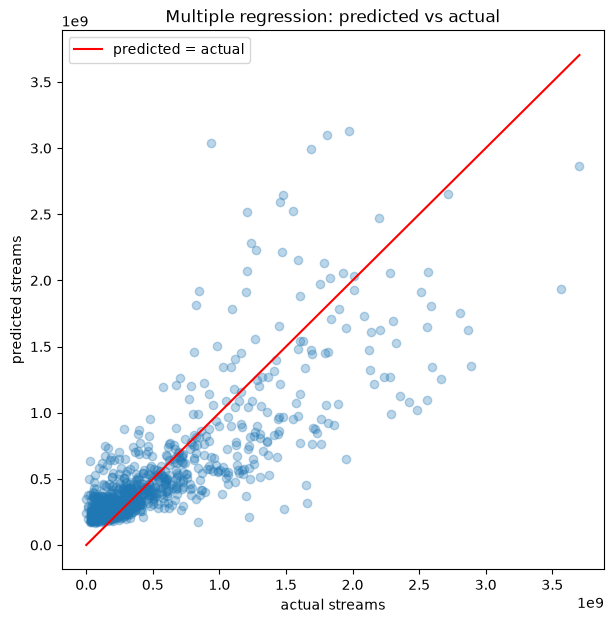

In [ ]:
# Multiple regression can't be shown as one 2D line (it lives in 4D),
# so we plot predicted vs actual instead.
plt.figure(figsize=(7, 7))
plt.scatter(y, predictions, alpha=0.3)                 # each song: actual vs predicted
plt.xlabel('actual streams')
plt.ylabel('predicted streams')

# the 45-degree "perfect prediction" reference line
lo = min(y.min(), predictions.min())
hi = max(y.max(), predictions.max())
plt.plot([lo, hi], [lo, hi], color='red', label='predicted = actual')

plt.title('Multiple regression: predicted vs actual')
plt.legend()
plt.show()